In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving bmw_global_sales_2018_2025.csv to bmw_global_sales_2018_2025.csv


In [ ]:
df=pd.read_csv("bmw_global_sales_2018_2025.csv")
df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3072 entries, 0 to 3071
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              3072 non-null   int64  
 1   Month             3072 non-null   int64  
 2   Region            3072 non-null   object 
 3   Model             3072 non-null   object 
 4   Units_Sold        3072 non-null   int64  
 5   Avg_Price_EUR     3072 non-null   int64  
 6   Revenue_EUR       3072 non-null   int64  
 7   BEV_Share         3072 non-null   float64
 8   Premium_Share     3072 non-null   float64
 9   GDP_Growth        3072 non-null   float64
 10  Fuel_Price_Index  3072 non-null   float64
dtypes: float64(4), int64(5), object(2)
memory usage: 264.1+ KB


In [ ]:
df.describe()

,Year,Month,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
count,3072.000000,3072.000000,3072.000000,3072.000000,3.072000e+03,3072.000000,3072.000000,3072.000000,3072.000000
mean,2021.500000,6.500000,7980.288086,63854.561523,5.113995e+08,0.107572,14.660234,3.057526,1.176224
std,2.291661,3.452615,3174.917444,14655.891299,2.431185e+08,0.058099,5.334604,1.018103,0.118123
min,2018.000000,1.000000,2379.000000,40011.000000,1.045314e+08,-0.015000,5.090000,0.100000,0.920000
25%,2019.750000,3.750000,5225.500000,54500.250000,3.125504e+08,0.057000,12.275000,2.370000,1.080000
50%,2021.500000,6.500000,7985.500000,63493.000000,4.808690e+08,0.108000,16.260000,3.060000,1.180000
75%,2023.250000,9.250000,10528.250000,71489.500000,6.709141e+08,0.157250,18.932500,3.852500,1.270000
max,2025.000000,12.000000,15914.000000,93994.000000,1.433482e+09,0.223000,20.970000,5.820000,1.410000


In [ ]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Units_Sold', 'Avg_Price_EUR',
       'Revenue_EUR', 'BEV_Share', 'Premium_Share', 'GDP_Growth',
       'Fuel_Price_Index'],
      dtype='object')

In [ ]:
eu_sales = df[df["Region"] == "Europe"]["Units_Sold"]
asia_sales = df[df["Region"] == "Asia"]["Units_Sold"]
t_stat, p_value = stats.ttest_ind(eu_sales, asia_sales)
print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: nan
P-value: nan


In [ ]:
alpha=0.05
if p_value<alpha:
  print("reject null hypothesis: sales differ between regions")
else:
  print("fail to reject nul hypothesis")

fail to reject nul hypothesis


In [ ]:
median_fuel = df["Fuel_Price_Index"].median()
high_fuel = df[df["Fuel_Price_Index"] > median_fuel]["Units_Sold"]
low_fuel = df[df["Fuel_Price_Index"] <= median_fuel]["Units_Sold"]
t_stat, p_value = stats.ttest_ind(high_fuel, low_fuel)
print("T-statistic :", t_stat)
print("P-value :", p_value)

T-statistic : 7.0558889132429
P-value : 2.1108182103923893e-12


In [ ]:
contigency_table=pd.crosstab(df["Region"],df["Model"])
from scipy.stats import chi2_contingency
chi2,p,dof,expected=chi2_contingency(contigency_table)
print("chi-square : ",chi2)
print("P value : ",p)

chi-square :  0.0
P value :  1.0


In [ ]:
if p<0.05:
  print("reject h0: model preference depends on region")
else:
  print("fail to reject h0")

fail to reject h0


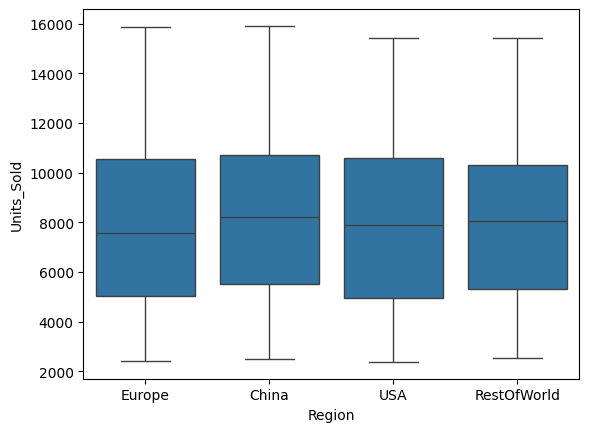

In [ ]:
sns.boxplot(x="Region",y="Units_Sold",data=df)
plt.title=("BMW Sales by Region")
plt.show()

In [ ]:
df_score = df[
    (df['BEV_Share'] > 0) &
    (df['Units_Sold'].notnull()) &
    (df['Avg_Price_EUR'].notnull())
][['Region','Model','Units_Sold','Avg_Price_EUR','BEV_Share']]
df_score

,Region,Model,Units_Sold,Avg_Price_EUR,BEV_Share
0,Europe,3 Series,7822,47482,0.011
1,Europe,5 Series,10280,61685,0.019
2,Europe,X3,3105,58433,0.022
3,Europe,X5,7420,67955,0.021
4,Europe,X7,8474,92300,0.035
...,...,...,...,...,...
3067,RestOfWorld,X5,9281,68198,0.201
3068,RestOfWorld,X7,12785,91839,0.203
3069,RestOfWorld,i4,4906,63437,0.180
3070,RestOfWorld,iX,7871,73867,0.196


In [ ]:
df_score = df[
    (df['Units_Sold'].notnull()) &
    (df['Revenue_EUR'].notnull())
][['Units_Sold','Revenue_EUR']]
df_score.head()

,Units_Sold,Revenue_EUR
0,7822,371404204
1,10280,634121800
2,3105,181434465
3,7420,504226100
4,8474,782150200


In [ ]:
from scipy.stats import ttest_rel
test_statistic, p_value = ttest_rel(
    df_score['Units_Sold'],
    df_score['Revenue_EUR'],
    alternative='less'
)
print("P-value:", p_value)
if p_value < 0.05:
    print("\nReject Null Hypothesis")
else:
    print("\nFail to Reject Null Hypothesis")

P-value: 0.0

Reject Null Hypothesis


In [ ]:
df_bev_high = df[
    (df['BEV_Share'] > 0.3) &
    (df['Units_Sold'].notnull()) &
    (df['Revenue_EUR'].notnull())
][['Region','Units_Sold','Revenue_EUR','BEV_Share']]
df_bev_high

,Region,Units_Sold,Revenue_EUR,BEV_Share


In [ ]:
df_bev_low = df[
    (df['BEV_Share'] <= 0.3) &
    (df['Units_Sold'].notnull()) &
    (df['Revenue_EUR'].notnull())
][['Region','Units_Sold','Revenue_EUR','BEV_Share']]
df_bev_low

,Region,Units_Sold,Revenue_EUR,BEV_Share
0,Europe,7822,371404204,0.011
1,Europe,10280,634121800,0.019
2,Europe,3105,181434465,0.022
3,Europe,7420,504226100,0.021
4,Europe,8474,782150200,0.035
...,...,...,...,...
3067,RestOfWorld,9281,632945638,0.201
3068,RestOfWorld,12785,1174161615,0.203
3069,RestOfWorld,4906,311221922,0.180
3070,RestOfWorld,7871,581407157,0.196


In [ ]:
df_score_no = df[
    (df['BEV_Share'] <= 0.3) &
    (df['Units_Sold'].notnull()) &
    (df['Revenue_EUR'].notnull())
][['Units_Sold','Revenue_EUR','BEV_Share']]
df_score_no.head()

,Units_Sold,Revenue_EUR,BEV_Share
0,7822,371404204,0.011
1,10280,634121800,0.019
2,3105,181434465,0.022
3,7420,504226100,0.021
4,8474,782150200,0.035


In [ ]:
from scipy.stats import ttest_rel
test_statistic, p_value = ttest_rel(
    df_score_no['Units_Sold'],
    df_score_no['Revenue_EUR'],
    alternative='less'
)
print("P-value:", p_value)
if p_value < 0.05:
    print("\nWe Reject Null Hypothesis")
else:
    print("\nFail to Reject Null Hypothesis")

P-value: 0.0

We Reject Null Hypothesis


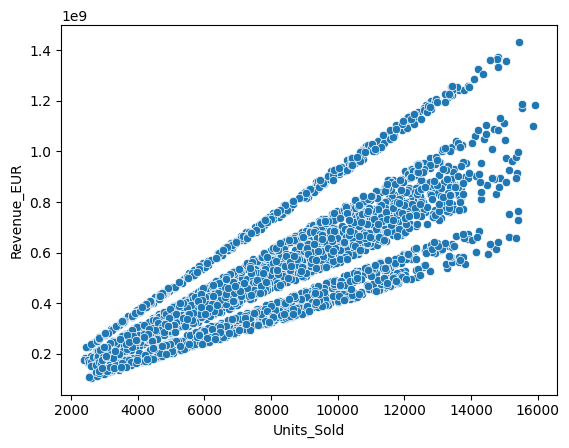

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x='Units_Sold', y='Revenue_EUR', data=df_score_no)
#plt.title("Relationship between Units Sold and Revenue")
plt.show()

In [ ]:
df['Region'].unique()

array(['Europe', 'China', 'USA', 'RestOfWorld'], dtype=object)

In [ ]:
df_europe = df[
    (df['Region'] == 'Europe') &
    (df['Units_Sold'].notnull())
][['Region','Model','Units_Sold','Avg_Price_EUR']]
df_usa = df[
    (df['Region'] == 'USA') &
    (df['Units_Sold'].notnull())
][['Region','Model','Units_Sold','Avg_Price_EUR']]

In [ ]:
df_europe = df_europe.sample(n=min(50, len(df_europe)), random_state=1)
df_usa = df_usa.sample(n=min(50, len(df_usa)), random_state=1)
display(df_europe.head())
display(df_usa.head())

,Region,Model,Units_Sold,Avg_Price_EUR
1125,Europe,i4,12400,65923
389,Europe,i4,6143,65896
2309,Europe,i4,8525,65922
1408,Europe,3 Series,8602,47121
2886,Europe,iX,7354,74189


,Region,Model,Units_Sold,Avg_Price_EUR
1141,USA,i4,13519,64116
405,USA,i4,3805,66566
2325,USA,i4,13021,64296
1424,USA,3 Series,5770,48059
2902,USA,iX,9630,75390


In [ ]:
from scipy.stats import ttest_ind
test_statistic, p_value = ttest_ind(
    df_europe['Units_Sold'],
    df_usa['Units_Sold']
)
print("P-value:", p_value)
if p_value < 0.05:
    print("\nReject Null Hypothesis")
else:
    print("\nFail to Reject Null Hypothesis")

P-value: 0.4437506541137456

Fail to Reject Null Hypothesis


In [ ]:
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(df['Region'], df['Model'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("P-value:", p)

P-value: 1.0


In [ ]:
df_china = df[
    (df['Region'] == 'China') &
    (df['Units_Sold'].notnull())
].sample(n=min(100, len(df[df['Region']=='China'])))[['Region','Model','Units_Sold','Avg_Price_EUR']]
display(df_china.head())
df_europe = df[
    (df['Region'] == 'Europe') &
    (df['Units_Sold'].notnull())
].sample(n=min(100, len(df[df['Region']=='Europe'])))[['Region','Model','Units_Sold','Avg_Price_EUR']]
display(df_europe.head())
df_usa = df[
    (df['Region'] == 'USA') &
    (df['Units_Sold'].notnull())
].sample(n=min(100, len(df[df['Region']=='USA'])))[['Region','Model','Units_Sold','Avg_Price_EUR']]
display(df_usa.head())
df_row = df[
    (df['Region'] == 'RestOfWorld') &
    (df['Units_Sold'].notnull())
].sample(n=min(100, len(df[df['Region']=='RestOfWorld'])))[['Region','Model','Units_Sold','Avg_Price_EUR']]
display(df_row.head())

,Region,Model,Units_Sold,Avg_Price_EUR
2347,China,X5,13308,70832
1326,China,iX,10377,73200
14,China,iX,3880,76461
620,China,X7,8210,92320
2313,China,5 Series,3669,60509


,Region,Model,Units_Sold,Avg_Price_EUR
2983,Europe,MINI,10913,42885
1891,Europe,X5,11862,69705
1255,Europe,MINI,6799,42845
2403,Europe,X5,4006,68716
2180,Europe,X7,6566,92812


,Region,Model,Units_Sold,Avg_Price_EUR
436,USA,X7,11380,92340
2867,USA,X5,8594,68531
3060,USA,X7,11744,92823
1266,USA,X3,6783,56972
820,USA,X7,8225,90256


,Region,Model,Units_Sold,Avg_Price_EUR
542,RestOfWorld,iX,7980,74312
2107,RestOfWorld,X5,7463,70083
189,RestOfWorld,i4,12069,66266
2047,RestOfWorld,MINI,6262,43758
2074,RestOfWorld,X3,8719,56253


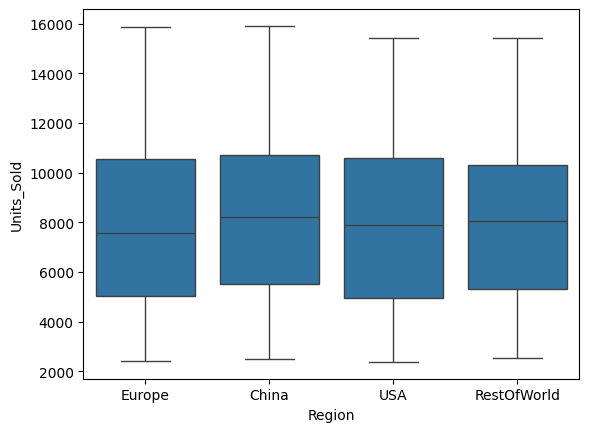

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x="Region", y="Units_Sold", data=df)
#plt.title("BMW Units Sold by Region")
plt.show()

In [ ]:
df_europe = df[df['Region'] == 'Europe']['Units_Sold'].dropna()
df_china = df[df['Region'] == 'China']['Units_Sold'].dropna()
df_usa = df[df['Region'] == 'USA']['Units_Sold'].dropna()
df_row = df[df['Region'] == 'RestOfWorld']['Units_Sold'].dropna()

In [ ]:
from scipy.stats import f_oneway
f_stats, p_value = f_oneway(
    df_europe,
    df_china,
    df_usa,
    df_row
)
print("P-value:", p_value)
if p_value < 0.05:
    print("\nReject Null Hypothesis")
else:
    print("\nFail to Reject Null Hypothesis")

P-value: 0.36824308433963804

Fail to Reject Null Hypothesis


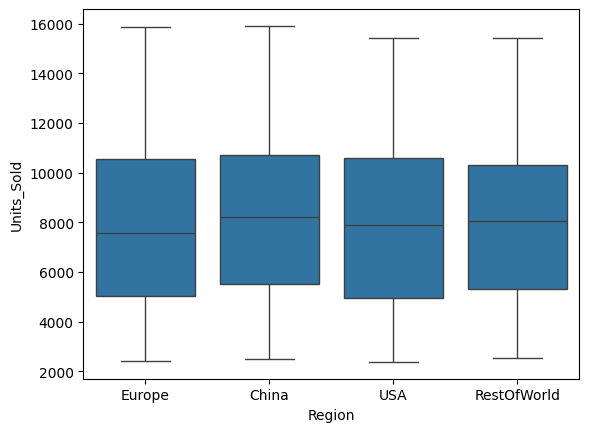

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x='Region', y='Units_Sold', data=df)
#plt.title("BMW Units Sold by Region")
plt.show()

In [ ]:
df_sample = df.sample(n=min(500, len(df)))

In [ ]:
df_obs_freq = pd.DataFrame({
    'observed_freq': df_sample.groupby(['Region']).size()
}).reset_index()
display(df_obs_freq)

,Region,observed_freq
0,China,126
1,Europe,123
2,RestOfWorld,132
3,USA,119


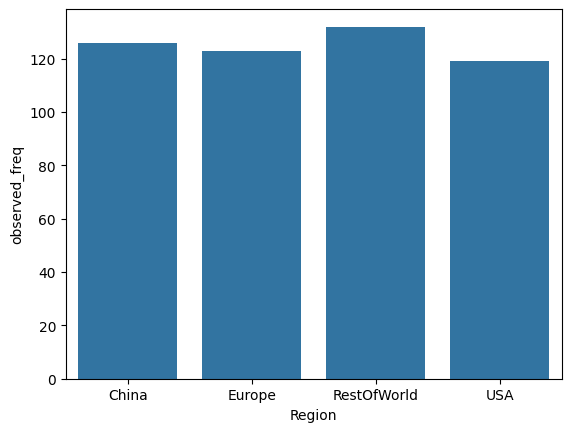

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(x='Region', y='observed_freq', data=df_obs_freq)
#plt.title("Observed Frequency of BMW Sales by Region")
plt.show()

In [ ]:
region = ['Europe', 'China', 'USA', 'RestOfWorld']


In [ ]:
rel_freq = [0.25, 0.25, 0.25, 0.25]

In [ ]:
df_region_freq = pd.DataFrame({
    'Region': region,
    'rel_freq': rel_freq
})
display(df_region_freq)

,Region,rel_freq
0,Europe,0.25
1,China,0.25
2,USA,0.25
3,RestOfWorld,0.25


In [ ]:
df_exp_freq = df_obs_freq.merge(df_region_freq, on='Region')
df_exp_freq['expected_freq'] = df_exp_freq['rel_freq'] * df_sample.shape[0]
display(df_exp_freq)

,Region,observed_freq,rel_freq,expected_freq
0,China,126,0.25,125.0
1,Europe,123,0.25,125.0
2,RestOfWorld,132,0.25,125.0
3,USA,119,0.25,125.0


In [ ]:
from scipy.stats import chisquare
test_statistic, p_value = chisquare(
    df_exp_freq['observed_freq'],
    df_exp_freq['expected_freq']
)
print("P-value:", p_value)
if p_value < 0.05:
    print("\nReject Null Hypothesis")
else:
    print("\nFail to Reject Null Hypothesis")

P-value: 0.8684899681806465

Fail to Reject Null Hypothesis


In [ ]:
df_region_model = pd.crosstab(df['Region'], df['Model'])
df_region_model

Model,3 Series,5 Series,MINI,X3,X5,X7,i4,iX
Region,,,,,,,,
China,96,96,96,96,96,96,96,96
Europe,96,96,96,96,96,96,96,96
RestOfWorld,96,96,96,96,96,96,96,96
USA,96,96,96,96,96,96,96,96


In [ ]:
df_region_model = pd.crosstab(df['Region'], df['Model'])
df_region_model

Model,3 Series,5 Series,MINI,X3,X5,X7,i4,iX
Region,,,,,,,,
China,96,96,96,96,96,96,96,96
Europe,96,96,96,96,96,96,96,96
RestOfWorld,96,96,96,96,96,96,96,96
USA,96,96,96,96,96,96,96,96


In [ ]:
from scipy.stats import chi2_contingency
test_statistic, p_value, x, c = chi2_contingency(df_region_model)
print("P-value:", p_value)
if p_value < 0.05:
    print("\nWe Reject Null Hypothesis")
else:
    print("\nFail to Reject Null Hypothesis")

P-value: 1.0

Fail to Reject Null Hypothesis
